# APPS Episode-Level RL Demo

This notebook implements **Pattern B** from our design discussion:

- **`reset()`** samples an APPS problem and returns a coding prompt.
- The **policy** produces a full completion (one episode).
- **`step(completion)`** runs a **sandbox** (no learned reward model) and returns `reward = test pass rate`.

The training section uses a **small candidate-selection policy** as a stand-in for an autoregressive LM. The env + sandbox code is what you would reuse with a real LLM + GRPO/PPO later.

**Requirements:** Python 3.10+, `apps/train.jsonl`, and the project venv (`gymnasium`, `torch`). Run `%pip install matplotlib` in the next cell if plots fail.

In [21]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\adosk\Documents\projects\cleanrl\.venv\Scripts\python.exe: No module named pip


In [22]:
import json
import random
import re
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium import spaces

# APPS test.jsonl contains huge integers; train.jsonl usually does not,
# but we set this defensively before any json.loads on dataset rows.
sys.set_int_max_str_digits(0)

APPS_DIR = Path(".").resolve()
TRAIN_PATH = APPS_DIR / "train.jsonl"
assert TRAIN_PATH.exists(), f"Missing {TRAIN_PATH} — run this notebook from the apps/ folder"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"APPS dir: {APPS_DIR}")
print(f"Device: {DEVICE}")

APPS dir: C:\Users\adosk\Documents\projects\cleanrl\apps
Device: cpu


## 1. Load a small training subset

We filter to **introductory**, **stdin/stdout** problems with short reference solutions so the sandbox stays fast in a notebook.

In [23]:
def load_apps_rows(
    path: Path,
    *,
    difficulty: str | None = "introductory",
    stdin_only: bool = True,
    max_tests: int = 2,
    max_solution_len: int = 200,
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for line in path.open(encoding="utf-8"):
        row = json.loads(line)
        if difficulty and row.get("difficulty") != difficulty:
            continue
        raw_io = row.get("input_output", "")
        if not raw_io.strip():
            continue
        io = json.loads(raw_io)
        if stdin_only and io.get("fn_name"):
            continue
        if len(io.get("inputs", [])) == 0 or len(io.get("inputs", [])) > max_tests:
            continue
        solutions = json.loads(row.get("solutions") or "[]")
        if not solutions or len(solutions[0]) > max_solution_len:
            continue
        rows.append(row)
    return rows


PROBLEMS = load_apps_rows(TRAIN_PATH)
print(f"Loaded {len(PROBLEMS)} candidate problems")

Loaded 47 candidate problems


## 2. Sandbox reward (no reward model)

The reward is **verifiable**: run extracted Python against APPS tests.

In [24]:
CODE_BLOCK_RE = re.compile(r"```(?:python)?\s*(.*?)```", re.DOTALL | re.IGNORECASE)


def extract_python(completion: str) -> str:
    """Pull code from a markdown block if present; otherwise treat the whole string as code."""
    match = CODE_BLOCK_RE.search(completion)
    if match:
        return match.group(1).strip()
    return completion.strip()


def normalize_output(text: str) -> str:
    """APPS expected outputs often have trailing spaces per line."""
    return "\n".join(line.rstrip() for line in str(text).strip().splitlines())


def format_prompt(question: str, starter_code: str = "") -> str:
    starter = starter_code.strip()
    if starter:
        return (
            "Solve the following problem by completing the Python code.\n\n"
            f"{question}\n\n"
            "Starter code:\n"
            f"```python\n{starter}\n```\n"
        )
    return (
        "Write a Python program that reads from stdin and prints to stdout.\n\n"
        f"{question}\n"
    )


def run_stdin_case(code: str, stdin: str, timeout: float = 2.0) -> tuple[bool, str, str]:
    try:
        proc = subprocess.run(
            [sys.executable, "-c", code],
            input=stdin,
            text=True,
            capture_output=True,
            timeout=timeout,
        )
    except subprocess.TimeoutExpired:
        return False, "", "timeout"
    ok = proc.returncode == 0
    return ok, proc.stdout, proc.stderr


@dataclass
class TestResult:
    passed: int
    total: int
    compile_ok: bool
    details: list[dict[str, Any]]

    @property
    def pass_rate(self) -> float:
        return self.passed / self.total if self.total else 0.0


def grade_code(code: str, io: dict[str, Any], *, timeout: float = 2.0) -> TestResult:
    inputs = io.get("inputs", [])
    outputs = io.get("outputs", [])
    details: list[dict[str, Any]] = []
    passed = 0
    compile_ok = True

    for idx, (inp, expected) in enumerate(zip(inputs, outputs)):
        if not isinstance(inp, str):
            compile_ok = False
            details.append({"case": idx, "ok": False, "stderr": "non-string stdin"})
            continue

        ok, got, err = run_stdin_case(code, inp, timeout=timeout)
        if err == "timeout":
            compile_ok = False
        if not ok and err and "SyntaxError" in err:
            compile_ok = False
        match = ok and normalize_output(got) == normalize_output(expected)
        passed += int(match)
        details.append(
            {
                "case": idx,
                "ok": match,
                "stderr": err[:200],
            }
        )

    return TestResult(passed=passed, total=len(inputs), compile_ok=compile_ok, details=details)


def validate_problem(row: dict[str, Any], *, timeout: float = 2.0) -> bool:
    """Keep only rows where the reference solution passes every sandbox test."""
    io = json.loads(row["input_output"])
    gold = json.loads(row["solutions"])[0]
    return grade_code(gold, io, timeout=timeout).pass_rate == 1.0

In [25]:
VALIDATED_PROBLEMS = [row for row in PROBLEMS if validate_problem(row)]
SMOKE_TEST_ID = VALIDATED_PROBLEMS[0]["id"]

print(f"Validated {len(VALIDATED_PROBLEMS)} / {len(PROBLEMS)} problems (reference solution passes all tests)")
print(f"Smoke-test problem id={SMOKE_TEST_ID}")

Validated 41 / 47 problems (reference solution passes all tests)
Smoke-test problem id=2383


## 3. Gymnasium environment (one episode = one submission)

The env does **not** generate tokens. It only:
1. samples a problem on `reset()`
2. grades a full completion on `step()`

In [26]:
class AppsCodeEnv(gym.Env):
    """Episode-level APPS coding env: one `step()` grades one full completion."""

    metadata = {"render_modes": []}

    def __init__(
        self,
        problems: list[dict[str, Any]],
        *,
        timeout: float = 2.0,
        seed: int = 0,
    ) -> None:
        super().__init__()
        self.problems = problems
        self.timeout = timeout
        self._rng = random.Random(seed)
        self.current: dict[str, Any] | None = None
        self.current_io: dict[str, Any] | None = None

        # Formal spaces; the training loop mostly uses info["prompt"].
        self.observation_space = spaces.Text(max_length=8192)
        self.action_space = spaces.Text(max_length=8192)

    def reset(self, *, seed: int | None = None, options: dict[str, Any] | None = None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng.seed(seed)
        if options and "problem_id" in options:
            pid = options["problem_id"]
            row = next(r for r in self.problems if r["id"] == pid)
        else:
            row = self._rng.choice(self.problems)

        self.current = row
        self.current_io = json.loads(row["input_output"])
        prompt = format_prompt(row["question"], row.get("starter_code", ""))

        obs = ""
        info = {
            "prompt": prompt,
            "problem_id": row["id"],
            "difficulty": row.get("difficulty"),
            "num_tests": len(self.current_io.get("inputs", [])),
        }
        return obs, info

    def step(self, action: str):
        assert self.current is not None and self.current_io is not None

        code = extract_python(action)
        result = grade_code(code, self.current_io, timeout=self.timeout)
        reward = float(result.pass_rate)

        terminated = True
        truncated = False
        info = {
            "passed": result.passed,
            "total": result.total,
            "compile_ok": result.compile_ok,
            "pass_rate": result.pass_rate,
            "details": result.details,
            "extracted_code": code,
        }
        return "", reward, terminated, truncated, info

## 4. Smoke test: reference solution should score 1.0

In [27]:
env = AppsCodeEnv(VALIDATED_PROBLEMS, seed=SEED)
_, info = env.reset(options={"problem_id": SMOKE_TEST_ID})
row = next(r for r in VALIDATED_PROBLEMS if r["id"] == info["problem_id"])
gold = json.loads(row["solutions"])[0]

_, reward_good, _, _, info_good = env.step(f"```python\n{gold}\n```")

_, info = env.reset(options={"problem_id": SMOKE_TEST_ID})
_, reward_bad, _, _, info_bad = env.step("```python\nprint('wrong')\n```")

print("Prompt preview:", info["prompt"][:240], "...\n")
print(f"Gold reward:  {reward_good:.2f} ({info_good['passed']}/{info_good['total']} tests)")
print(f"Bad reward:   {reward_bad:.2f} ({info_bad['passed']}/{info_bad['total']} tests)")

Prompt preview: Write a Python program that reads from stdin and prints to stdout.

Find the minimum area of a square land on which you can place two identical rectangular $a \times b$ houses. The sides of the houses should be parallel to the sides of the  ...

Gold reward:  1.00 (1/1 tests)
Bad reward:   0.00 (0/1 tests)


## 5. Mini GRPO-style training loop

Full LM fine-tuning is heavy for a notebook, so we use a **candidate policy** as a stand-in:

- Five **fixed-quality** completions per problem (bad → good). Slot 4 is always the reference solution.
- A small network reads a prompt embedding and picks a candidate index.
- We sample a **group** of candidates and apply **group-relative advantages** (GRPO-style).

**Important:** we do **not** shuffle candidates. If the good solution moves to a random slot every episode, the policy cannot learn a stable action — that was the cause of the noisy up/down reward plot in the earlier version.

Replace candidate selection with `lm.generate(prompt)` when you move to a real autoregressive policy.

In [28]:
import hashlib

GOLD_CANDIDATE_IDX = 4


def embed_text(text: str, dim: int = 256) -> torch.Tensor:
    """Stable bag-of-words embedding (Python's built-in hash is randomized per process)."""
    vec = torch.zeros(dim)
    for token in text.lower().split()[:256]:
        digest = hashlib.md5(token.encode("utf-8")).hexdigest()
        vec[int(digest, 16) % dim] += 1.0
    norm = vec.norm()
    return vec / norm if norm > 0 else vec


def build_candidates(row: dict[str, Any]) -> list[str]:
    """Fixed-order candidates: slot 4 is always the passing reference solution.

    In production RL, completions come from `policy.generate(prompt)` instead.
    """
    gold = json.loads(row["solutions"])[0]
    broken = gold.replace("print(", "prnt(", 1) if "print(" in gold else gold + "\nraise Exception('bug')"
    truncated = gold[: max(1, len(gold) // 2)]
    return [
        "```python\nprint('placeholder')\n```",  # 0: always bad
        f"```python\n{broken}\n```",  # 1: syntax/runtime bug
        f"```python\n{truncated}\n```",  # 2: incomplete
        f"```python\n{gold}\n# trailing comment\n```",  # 3: good
        f"```python\n{gold}\n```",  # 4: gold
    ]


class CandidatePolicy(nn.Module):
    def __init__(self, input_dim: int = 256, n_candidates: int = 5) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.Tanh(),
            nn.Linear(128, n_candidates),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


@dataclass
class EpisodeLog:
    episode: int
    group_mean: float
    group_max: float
    gold_prob: float
    problem_id: int

In [29]:
NUM_EPISODES = 250
GROUP_SIZE = 4
LEARNING_RATE = 5e-3
N_CANDIDATES = 5

train_env = AppsCodeEnv(VALIDATED_PROBLEMS, seed=SEED)
policy = CandidatePolicy(n_candidates=N_CANDIDATES).to(DEVICE)
optimizer = torch.optim.Adam(policy.parameters(), lr=LEARNING_RATE)

group_mean_history: list[float] = []
group_max_history: list[float] = []
gold_prob_history: list[float] = []
logs: list[EpisodeLog] = []

for episode in range(NUM_EPISODES):
    # Cycle deterministically so the policy sees the same problem multiple times.
    row = VALIDATED_PROBLEMS[episode % len(VALIDATED_PROBLEMS)]
    _, reset_info = train_env.reset(options={"problem_id": row["id"]})
    prompt = reset_info["prompt"]
    candidates = build_candidates(row)

    features = embed_text(prompt).to(DEVICE)
    logits = policy(features)
    probs = F.softmax(logits, dim=-1)

    sampled_indices = torch.multinomial(probs, num_samples=GROUP_SIZE, replacement=True)
    group_rewards: list[float] = []
    group_logprobs: list[torch.Tensor] = []

    for idx in sampled_indices:
        candidate_idx = int(idx.item())
        _, reward, _, _, _ = train_env.step(candidates[candidate_idx])
        group_rewards.append(reward)
        group_logprobs.append(torch.log(probs[candidate_idx] + 1e-8))

    reward_tensor = torch.tensor(group_rewards, device=DEVICE, dtype=torch.float32)
    group_mean = float(reward_tensor.mean().item())
    group_max = float(reward_tensor.max().item())
    advantages = reward_tensor - reward_tensor.mean()

    loss = torch.zeros((), device=DEVICE)
    for logprob, adv in zip(group_logprobs, advantages):
        loss = loss - logprob * adv
    loss = loss / GROUP_SIZE

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    gold_prob = float(probs[GOLD_CANDIDATE_IDX].detach().item())
    group_mean_history.append(group_mean)
    group_max_history.append(group_max)
    gold_prob_history.append(gold_prob)
    logs.append(
        EpisodeLog(
            episode=episode,
            group_mean=group_mean,
            group_max=group_max,
            gold_prob=gold_prob,
            problem_id=row["id"],
        )
    )

    if episode % 50 == 0 or episode == NUM_EPISODES - 1:
        recent = group_mean_history[max(0, episode - 49) : episode + 1]
        print(
            f"episode {episode:3d} | "
            f"group_mean={group_mean:.2f} | "
            f"group_max={group_max:.2f} | "
            f"P(gold)={gold_prob:.2f} | "
            f"avg50={np.mean(recent):.2f}"
        )

print("\nTraining finished.")
print(f"Final P(gold slot): {gold_prob_history[-1]:.3f}")
print(f"Final 50-episode avg group mean: {np.mean(group_mean_history[-50:]):.3f}")

episode   0 | group_mean=0.50 | group_max=1.00 | P(gold)=0.19 | avg50=0.50
episode  50 | group_mean=1.00 | group_max=1.00 | P(gold)=0.84 | avg50=0.90
episode 100 | group_mean=1.00 | group_max=1.00 | P(gold)=0.83 | avg50=1.00
episode 150 | group_mean=1.00 | group_max=1.00 | P(gold)=0.80 | avg50=1.00
episode 200 | group_mean=1.00 | group_max=1.00 | P(gold)=0.82 | avg50=1.00
episode 249 | group_mean=1.00 | group_max=1.00 | P(gold)=0.82 | avg50=1.00

Training finished.
Final P(gold slot): 0.818
Final 50-episode avg group mean: 1.000


## 6. Reward visualization

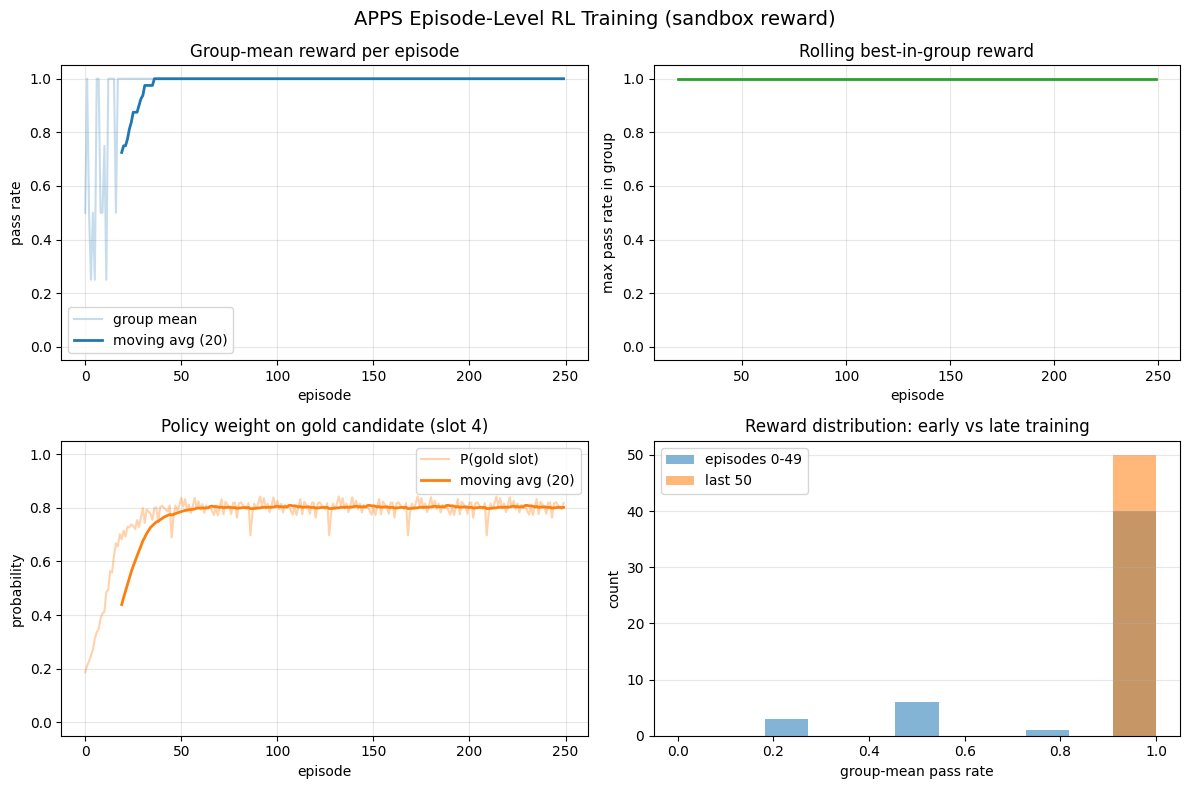

Early 50-episode avg group mean: 0.890
Late  50-episode avg group mean: 1.000
Early P(gold): 0.635  ->  Late P(gold): 0.804


In [30]:
def moving_average(values: list[float], window: int = 20) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float32)
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode="valid")


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("APPS Episode-Level RL Training (sandbox reward)", fontsize=14)

# 1) Group-mean reward (primary training signal — much smoother than one random sample)
ax = axes[0, 0]
ax.plot(group_mean_history, alpha=0.25, color="tab:blue", label="group mean")
ax.plot(
    np.arange(19, len(group_mean_history)),
    moving_average(group_mean_history, window=20),
    linewidth=2,
    color="tab:blue",
    label="moving avg (20)",
)
ax.set_title("Group-mean reward per episode")
ax.set_xlabel("episode")
ax.set_ylabel("pass rate")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

# 2) Best reward in each sampled group
ax = axes[0, 1]
ax.plot(
    np.arange(19, len(group_max_history)),
    moving_average(group_max_history, window=20),
    linewidth=2,
    color="tab:green",
)
ax.set_title("Rolling best-in-group reward")
ax.set_xlabel("episode")
ax.set_ylabel("max pass rate in group")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# 3) Policy probability on the gold candidate slot
ax = axes[1, 0]
ax.plot(gold_prob_history, alpha=0.35, color="tab:orange", label="P(gold slot)")
ax.plot(
    np.arange(19, len(gold_prob_history)),
    moving_average(gold_prob_history, window=20),
    linewidth=2,
    color="tab:orange",
    label="moving avg (20)",
)
ax.set_title("Policy weight on gold candidate (slot 4)")
ax.set_xlabel("episode")
ax.set_ylabel("probability")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

# 4) Histogram of group-mean rewards (early vs late)
ax = axes[1, 1]
early = group_mean_history[:50]
late = group_mean_history[-50:]
ax.hist(early, bins=11, range=(0, 1), alpha=0.55, label="episodes 0-49")
ax.hist(late, bins=11, range=(0, 1), alpha=0.55, label="last 50")
ax.set_title("Reward distribution: early vs late training")
ax.set_xlabel("group-mean pass rate")
ax.set_ylabel("count")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Early 50-episode avg group mean: {np.mean(group_mean_history[:50]):.3f}")
print(f"Late  50-episode avg group mean: {np.mean(group_mean_history[-50:]):.3f}")
print(f"Early P(gold): {np.mean(gold_prob_history[:50]):.3f}  ->  Late P(gold): {np.mean(gold_prob_history[-50:]):.3f}")

## 7. Evaluate one episode interactively

In [31]:
eval_env = AppsCodeEnv(VALIDATED_PROBLEMS, seed=SEED + 1)
_, eval_info = eval_env.reset(options={"problem_id": SMOKE_TEST_ID})
row = next(r for r in VALIDATED_PROBLEMS if r["id"] == eval_info["problem_id"])
candidates = build_candidates(row)

features = embed_text(eval_info["prompt"]).to(DEVICE)
with torch.no_grad():
    probs = F.softmax(policy(features), dim=-1)
    idx = int(torch.argmax(probs).item())

completion = candidates[idx]
_, reward, _, _, step_info = eval_env.step(completion)

print("Problem id:", eval_info["problem_id"])
print("Picked candidate slot:", idx, "(4 = gold reference)")
print("Reward:", reward)
print("Passed:", f"{step_info['passed']}/{step_info['total']}")
print("P(gold):", float(probs[GOLD_CANDIDATE_IDX].item()))
print("\nSubmitted code:\n")
print(step_info["extracted_code"])

Problem id: 2383
Picked candidate slot: 4 (4 = gold reference)
Reward: 1.0
Passed: 1/1
P(gold): 0.8110872507095337

Submitted code:

T = int(input())

for _ in range(T):
    a, b = list(map(int, input().split()))
    print(max(max(a, b), min(a, b) * 2)**2)


## 8. Next steps: plug in a real autoregressive policy

Keep `AppsCodeEnv` and `grade_code()` as-is. Swap only the policy side:

```python
_, info = env.reset()
completion = lm.generate(info["prompt"])  # autoregressive tokens
_, reward, _, _, info = env.step(completion)
# GRPO/PPO update on token logprobs using reward
```

Recommended path:
1. SFT on APPS `solutions` (behavior cloning).
2. GRPO with sandbox reward on stdin/stdout train rows.
3. Add `fn_name` execution + starter-code completion tasks.
4. Evaluate on held-out rows (use `test.jsonl` sparingly; it is much larger).